1. 实验设置

主要进行两类测试：

- 测试 1：在 batch size=1 的情况下，测试不同的推理方式在不同 prompt 长度和 decode 长度下的性能，推理方式包括：
  - 自定义 Generator
  - Mini-Inference Triton Eager
  - Mini-Inference Triton CUDA Graph
  - Mini-Inference flash-attn CUDA Graph
- 测试 2：Continuous Batching，测试不同并发请求数下，Mini-Inference Triton CUDA Graph 的性能表现

In [1]:
import atexit
import gc
from itertools import product
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoTokenizer

from mini_models import Generator, MiniLlama3Config, MiniLlama3ForCausalLM
from mini_inference import LLM, SamplingParams


if not torch.cuda.is_available():
    raise RuntimeError("This benchmark requires a CUDA device")

weight_path = "../output/sft_mini_llama3"
tokenizer_path = "../mini_tokenizer"

# 测试 1 配置
prompt_lengths = [128, 256, 512, 1024, 2048, 4096]
decode_lengths = [64, 128, 256, 512]
batch_1_cases = [(prompt_lengths[0], length) for length in decode_lengths]  # 测试不同 decode 长度时，prompt 长度固定为 128
batch_1_cases.extend((length, 1) for length in prompt_lengths[1:])  # 测试不同 prompt 长度时，decode 长度固定为 1
warmup_runs = 1
repeats = 5

# 测试 2 配置
concurrency_levels = [1, 4, 8, 16, 32]
num_requests = 64
continuous_prompt_lengths = [128, 256, 512, 1024]
continuous_decode_lengths = [64, 128, 256, 512]

max_model_len = max(
    max(prompt_length + decode_length for prompt_length, decode_length in batch_1_cases),
    max(continuous_prompt_lengths) + max(continuous_decode_lengths),
)
max_num_batched_tokens = 16384
max_num_seqs = max(concurrency_levels)
dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

plt.style.use("seaborn-v0_8-whitegrid")
colors = {
    "Generator": "#4C78A8",
    "Mini-Inference Triton Eager": "#F58518",
    "Mini-Inference Triton Graph": "#54A24B",
    "Mini-Inference flash-attn Graph": "#E45756",
}

print("GPU:", torch.cuda.get_device_name(0))
print("Dtype:", dtype)
print("Max model length:", max_model_len)

GPU: NVIDIA GeForce RTX 5090 D v2
Dtype: torch.bfloat16
Max model length: 4097


2. 构建输入

In [2]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
prompt_pattern = tokenizer.encode(
    "Mini-LLM inference throughput benchmark.",
    add_special_tokens=False,
)


# 构建 prompt 的函数，prompt 的第一个 token 会根据 prompt_id 进行修改，避免 prefix cache 的影响
def make_prompt(length: int, prompt_id: int) -> list[int]:
    repeats = (length + len(prompt_pattern) - 1) // len(prompt_pattern)
    token_ids = (prompt_pattern * repeats)[:length]  # 截断到指定长度
    token_ids[0] = (token_ids[0] + prompt_id + 1) % tokenizer.vocab_size
    return token_ids


# 构建 continuous batching 测试的 workload
def build_workload(prompt_offset: int) -> list[dict]:
    cases = list(product(continuous_prompt_lengths, continuous_decode_lengths))  # 所有 prompt 长度和 decode 长度的组合
    workload = []
    for request_id in range(num_requests):
        prompt_length, decode_length = cases[request_id % len(cases)]  # 循环使用 cases 中的组合
        workload.append({
            "request_id": request_id,
            "prompt_length": prompt_length,
            "decode_length": decode_length,
            "token_ids": make_prompt(prompt_length, prompt_offset + request_id),
        })
    return workload

3. 构建测试 1 测试函数

In [3]:
# 同步 CUDA 设备，确保所有操作完成
def synchronize():
    torch.cuda.synchronize()


# 加载模型
def build_llm(attention_backend: str, enforce_eager: bool, max_seqs: int) -> LLM:
    config = MiniLlama3Config.from_pretrained(weight_path)
    config.max_position_embeddings = max_model_len
    return LLM(
        str(weight_path),
        tokenizer_path=str(tokenizer_path),
        tensor_parallel_size=1,
        max_num_batched_tokens=max_num_batched_tokens,
        max_num_seqs=max_seqs,
        max_model_len=max_model_len,
        hf_config=config,
        gpu_memory_utilization=0.3,
        dtype=dtype,
        enforce_eager=enforce_eager,
        attention_backend=attention_backend,
    )


# 释放 LLM 资源
def release_llm(llm: LLM) -> None:
    atexit.unregister(llm.exit)
    llm.exit()
    gc.collect()
    torch.cuda.empty_cache()


# 自定义 Generator 推理
@torch.inference_mode()
def benchmark_generator(
    generator: Generator,
    token_ids: list[int],
    decode_length: int,
) -> tuple[float, float]:
    input_ids = torch.tensor([token_ids], dtype=torch.long, device=generator.model.device)

    # prefill
    synchronize()
    start = perf_counter()
    outputs = generator.model(input_ids=input_ids, use_cache=True, logits_to_keep=1)
    next_token = outputs.logits[:, -1].argmax(dim=-1, keepdim=True)
    next_token.item()
    synchronize()
    prefill_time = perf_counter() - start
    past_key_values = outputs.past_key_values

    # decode
    synchronize()
    start = perf_counter()
    for _ in range(decode_length - 1):
        outputs = generator.model(
            input_ids=next_token,
            past_key_values=past_key_values,
            use_cache=True,
            logits_to_keep=1,
        )
        next_token = outputs.logits[:, -1].argmax(dim=-1, keepdim=True)
        next_token.item()
        past_key_values = outputs.past_key_values
    synchronize()
    decode_time = perf_counter() - start
    return prefill_time, decode_time


# Mini Inference 推理
def benchmark_mini_inference(
    llm: LLM,
    token_ids: list[int],
    decode_length: int,
) -> tuple[float, float]:
    seq = llm.add_request(
        token_ids,
        SamplingParams(temperature=0.0, max_tokens=decode_length, ignore_eos=True),
    )

    # 这里包含了调度开销
    # prefill
    synchronize()
    start = perf_counter()
    llm.step()
    synchronize()
    prefill_time = perf_counter() - start

    # decode
    synchronize()
    start = perf_counter()
    while not seq.is_finished:
        llm.step()
    synchronize()
    decode_time = perf_counter() - start
    return prefill_time, decode_time


# 运行 batch 1 的 benchmark 测试
def run_batch_1_benchmark(name: str, benchmark_func) -> list[dict]:
    records = []
    prompt_id = 0
    total = len(batch_1_cases) * (warmup_runs + repeats)  # 计算总的测试次数
    progress = tqdm(total=total, desc=name)

    for prompt_length, decode_length in batch_1_cases:
        for _ in range(warmup_runs):
            benchmark_func(make_prompt(prompt_length, prompt_id), decode_length)
            prompt_id += 1
            progress.update(1)

        for repeat in range(repeats):
            prefill_time, decode_time = benchmark_func(
                make_prompt(prompt_length, prompt_id),
                decode_length,
            )
            prompt_id += 1
            records.append({
                "backend": name,
                "prompt_tokens": prompt_length,
                "decode_tokens": decode_length,
                "repeat": repeat,
                "prefill_tok_s": prompt_length / prefill_time,
                "decode_tok_s": (decode_length - 1) / decode_time if decode_length > 1 else None,
                "ttft_ms": prefill_time * 1000,
            })
            progress.update(1)

    progress.close()
    return records

4. 运行测试 1

(1) 自定义 Generator

In [4]:
# 加载模型
model_config = MiniLlama3Config.from_pretrained(weight_path)
model_config.max_position_embeddings = max_model_len
model = MiniLlama3ForCausalLM.from_pretrained(
    weight_path,
    config=model_config,
    dtype=dtype,
).cuda().eval()
generator = Generator(model, tokenizer)

generator_records = run_batch_1_benchmark(
    "Generator",
    lambda token_ids, decode_length: benchmark_generator(
        generator, token_ids, decode_length
    ),
)

del generator, model
gc.collect()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/110 [00:00<?, ?it/s]

Generator:   0%|          | 0/54 [00:00<?, ?it/s]

(2) Mini-Inference Triton Eager

In [5]:
triton_eager_llm = build_llm("triton", enforce_eager=True, max_seqs=1)
triton_eager_records = run_batch_1_benchmark(
    "Mini-Inference Triton Eager",
    lambda token_ids, decode_length: benchmark_mini_inference(
        triton_eager_llm, token_ids, decode_length
    ),
)
release_llm(triton_eager_llm)
del triton_eager_llm

Mini-Inference Triton Eager:   0%|          | 0/54 [00:00<?, ?it/s]

(3) Mini-Inference Triton CUDA Graph

In [6]:
triton_graph_llm = build_llm("triton", enforce_eager=False, max_seqs=1)
triton_graph_records = run_batch_1_benchmark(
    "Mini-Inference Triton Graph",
    lambda token_ids, decode_length: benchmark_mini_inference(
        triton_graph_llm, token_ids, decode_length
    ),
)
release_llm(triton_graph_llm)
del triton_graph_llm

Mini-Inference Triton Graph:   0%|          | 0/54 [00:00<?, ?it/s]

(4) Mini-Inference flash-attn CUDA Graph

In [7]:
flash_graph_llm = build_llm("flash_attn", enforce_eager=False, max_seqs=1)
flash_graph_records = run_batch_1_benchmark(
    "Mini-Inference flash-attn Graph",
    lambda token_ids, decode_length: benchmark_mini_inference(
        flash_graph_llm, token_ids, decode_length
    ),
)
release_llm(flash_graph_llm)
del flash_graph_llm

batch_1_results = pd.DataFrame(
    generator_records
    + triton_eager_records
    + triton_graph_records
    + flash_graph_records
)

Mini-Inference flash-attn Graph:   0%|          | 0/54 [00:00<?, ?it/s]

5. 测试 1 结果

In [8]:
# prefill 阶段不涉及 CUDA Graph 的使用，因此选取 Mini-Inference Triton Eager 作为 Triton 的性能代表
prefill_backend_names = {
    "Generator": "Generator",
    "Mini-Inference Triton Eager": "Mini + Triton",
    "Mini-Inference flash-attn Graph": "Mini + flash-attn",
}
prefill_results = (
    batch_1_results[batch_1_results["backend"].isin(prefill_backend_names)]
    .groupby(["backend", "prompt_tokens"], as_index=False)["prefill_tok_s"]
    .mean()
)
prefill_results["backend"] = prefill_results["backend"].map(prefill_backend_names)

decode_results = (
    batch_1_results[batch_1_results["decode_tokens"] > 1]
    .groupby(["backend", "decode_tokens"], as_index=False)["decode_tok_s"]
    .mean()
)
decode_pivot = decode_results.pivot(
    index="decode_tokens",
    columns="backend",
    values="decode_tok_s",
)
decode_attribution = pd.DataFrame({
    "Mini Triton Eager / Generator": decode_pivot["Mini-Inference Triton Eager"] / decode_pivot["Generator"],
    "Mini Triton Graph / Mini Triton Eager": decode_pivot["Mini-Inference Triton Graph"] / decode_pivot["Mini-Inference Triton Eager"],
    "Mini Triton Graph / Generator": decode_pivot["Mini-Inference Triton Graph"] / decode_pivot["Generator"],
    "Mini Triton Graph / Mini flash-attn Graph": decode_pivot["Mini-Inference Triton Graph"] / decode_pivot["Mini-Inference flash-attn Graph"],
})

display(prefill_results.round(1))
display(decode_results.round(1))
display(decode_attribution.round(3))

,backend,prompt_tokens,prefill_tok_s
0,Generator,128,31552.3
1,Generator,256,73773.4
2,Generator,512,149055.2
3,Generator,1024,199241.7
4,Generator,2048,97528.3
5,Generator,4096,51958.6
6,Mini + Triton,128,21346.8
7,Mini + Triton,256,49604.6
8,Mini + Triton,512,98364.1
9,Mini + Triton,1024,196582.0


,backend,decode_tokens,decode_tok_s
0,Generator,64,321.3
1,Generator,128,320.5
2,Generator,256,314.2
3,Generator,512,321.7
4,Mini-Inference Triton Eager,64,227.3
5,Mini-Inference Triton Eager,128,225.3
6,Mini-Inference Triton Eager,256,224.8
7,Mini-Inference Triton Eager,512,229.6
8,Mini-Inference Triton Graph,64,1848.9
9,Mini-Inference Triton Graph,128,1824.2


,Mini Triton Eager / Generator,Mini Triton Graph / Mini Triton Eager,Mini Triton Graph / Generator,Mini Triton Graph / Mini flash-attn Graph
decode_tokens,,,,
64,0.708,8.134,5.755,1.115
128,0.703,8.095,5.691,1.097
256,0.715,7.822,5.595,1.047
512,0.714,7.165,5.114,0.982


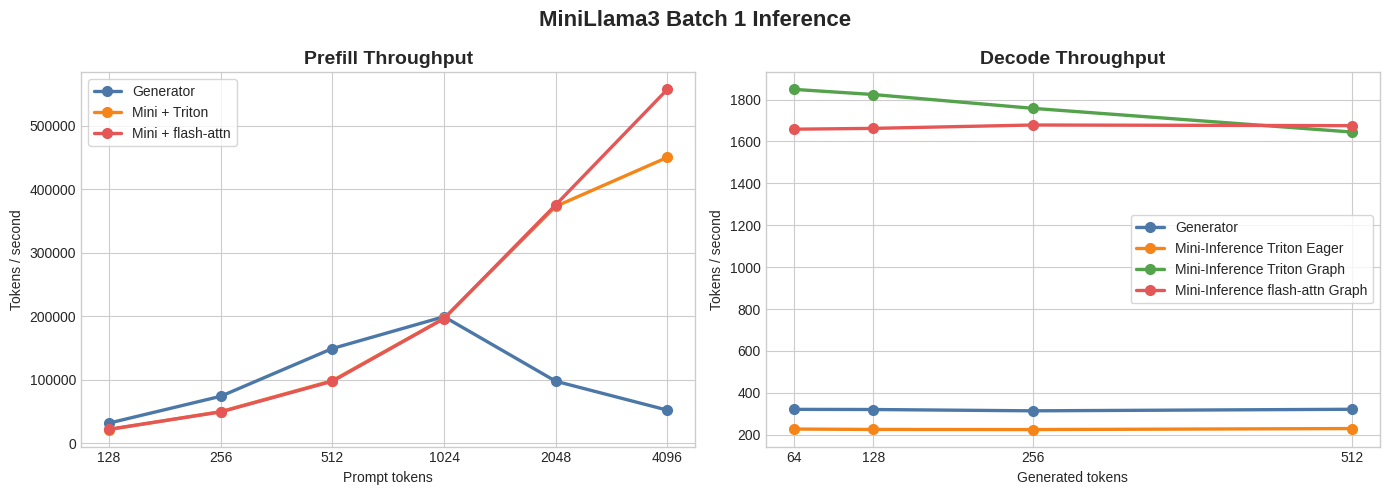

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prefill_colors = ["#4C78A8", "#F58518", "#E45756"]
for color, (backend, data) in zip(prefill_colors, prefill_results.groupby("backend", sort=False)):
    axes[0].plot(
        data["prompt_tokens"],
        data["prefill_tok_s"],
        marker="o",
        linewidth=2.4,
        markersize=7,
        color=color,
        label=backend,
    )
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(prompt_lengths, labels=prompt_lengths)
axes[0].set_title("Prefill Throughput", fontsize=14, weight="bold")
axes[0].set_xlabel("Prompt tokens")
axes[0].set_ylabel("Tokens / second")
axes[0].legend(frameon=True)

for backend, data in decode_results.groupby("backend", sort=False):
    axes[1].plot(
        data["decode_tokens"],
        data["decode_tok_s"],
        marker="o",
        linewidth=2.4,
        markersize=7,
        color=colors[backend],
        label=backend,
    )
axes[1].set_xticks(decode_lengths)
axes[1].set_title("Decode Throughput", fontsize=14, weight="bold")
axes[1].set_xlabel("Generated tokens")
axes[1].set_ylabel("Tokens / second")
axes[1].legend(frameon=True)

fig.suptitle("MiniLlama3 Batch 1 Inference", fontsize=16, weight="bold")
fig.tight_layout()
plt.show()

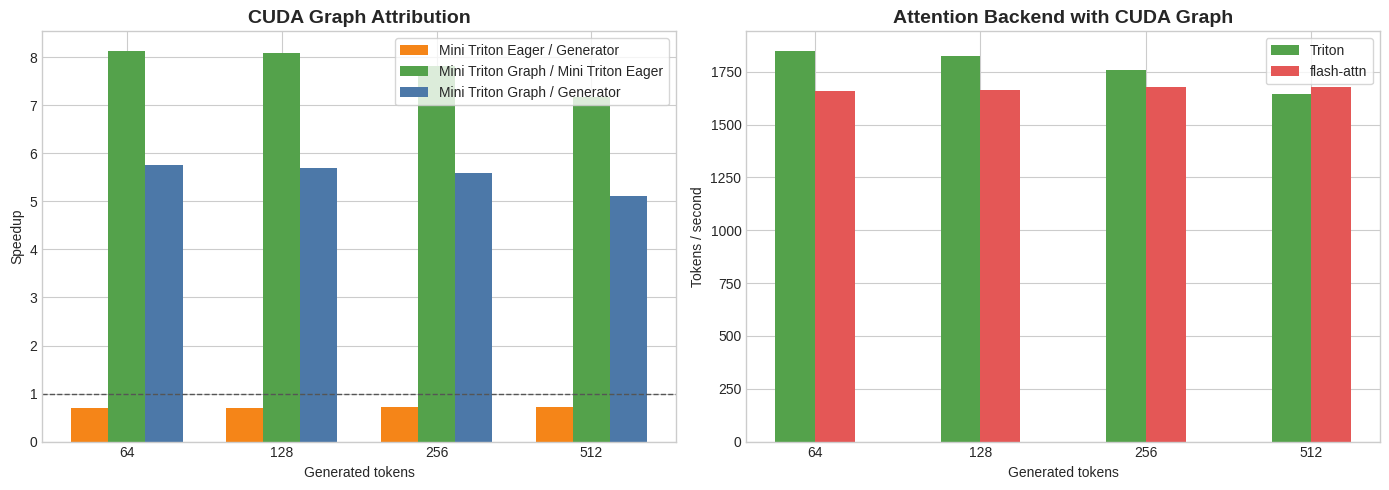

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(decode_attribution.index))
width = 0.24

attribution_columns = [
    ("Mini Triton Eager / Generator", "Mini Triton Eager / Generator", "#F58518"),
    ("Mini Triton Graph / Mini Triton Eager", "Mini Triton Graph / Mini Triton Eager", "#54A24B"),
    ("Mini Triton Graph / Generator", "Mini Triton Graph / Generator", "#4C78A8"),
]
for offset, (column, label, color) in enumerate(attribution_columns):
    axes[0].bar(
        x + (offset - 1) * width,
        decode_attribution[column],
        width,
        label=label,
        color=color,
    )
axes[0].axhline(1.0, color="#555555", linewidth=1, linestyle="--")
axes[0].set_xticks(x, decode_attribution.index)
axes[0].set_title("CUDA Graph Attribution", fontsize=14, weight="bold")
axes[0].set_xlabel("Generated tokens")
axes[0].set_ylabel("Speedup")
axes[0].legend(frameon=True)

backend_compare = decode_pivot[["Mini-Inference Triton Graph", "Mini-Inference flash-attn Graph"]]
axes[1].bar(x - width / 2, backend_compare["Mini-Inference Triton Graph"], width, color="#54A24B", label="Triton")
axes[1].bar(x + width / 2, backend_compare["Mini-Inference flash-attn Graph"], width, color="#E45756", label="flash-attn")
axes[1].set_xticks(x, backend_compare.index)
axes[1].set_title("Attention Backend with CUDA Graph", fontsize=14, weight="bold")
axes[1].set_xlabel("Generated tokens")
axes[1].set_ylabel("Tokens / second")
axes[1].legend(frameon=True)

fig.tight_layout()
plt.show()

测试 1 结果分析

- Prefill：短 prompt 下，Mini-Inference 的调度、paged kv cache 准备和 kernel 启动等固定开销占比较高，因此 prefill 吞吐不如 Generator。随着 prompt 变长，attention 计算逐渐成为主要开销，Mini + Triton 和 Mini + flash-attn 的优势开始显现，并在长序列下明显领先 Generator。两种 Mini-Inference prefill backend 在中短序列下表现接近，长序列下 flash-attn 更有优势，说明当前自定义 triton prefill kernel 仍有优化空间。
- Decode：batch 1 decode 每一步只处理一个 token，计算的算术强度较低，同样受调度、kernel 启动等开销影响较大，无法通过 triton 优化摊薄开销，因此整体慢于 Generator。启用 CUDA Graph 后，Mini Triton Graph 的 decode 吞吐显著提高，说明本次 batch 1 decode 的主要加速来源是减少逐 token 的 CPU 调度和 kernel 提交开销。相同 CUDA Graph 路径下，自定义 triton decode 与 flash-attn 大致处于同一性能水平。

6. 构建测试 2 测试函数

In [11]:
# warmup
def warmup_continuous_batching(llm: LLM, concurrency: int, prompt_offset: int) -> None:
    for request_id in range(concurrency):
        llm.add_request(
            make_prompt(128, prompt_offset + request_id),
            SamplingParams(temperature=0.0, max_tokens=8, ignore_eos=True),
        )
    while not llm.is_finished():
        llm.step()
    synchronize()


# 运行 continuous batching 的 benchmark 测试
def benchmark_continuous_batching(
    llm: LLM,
    workload: list[dict],
    concurrency: int,
) -> tuple[dict, pd.DataFrame]:
    next_request = 0
    active = {}
    request_rows = []
    decode_batch_sizes = []

    def admit_request(spec: dict) -> None:
        seq = llm.add_request(
            spec["token_ids"],
            SamplingParams(
                temperature=0.0,
                max_tokens=spec["decode_length"],
                ignore_eos=True,
            ),
        )
        active[seq.seq_id] = {
            "seq": seq,
            "request_id": spec["request_id"],
            "prompt_length": spec["prompt_length"],
            "admitted_at": perf_counter(),
            "first_token_at": None,
        }

    synchronize()
    torch.cuda.reset_peak_memory_stats()  # 重置 CUDA 显存峰值统计
    benchmark_start = perf_counter()

    # 预先添加请求，直到达到并发限制
    while next_request < len(workload) and len(active) < concurrency:
        admit_request(workload[next_request])  # 添加请求，并记录 active 相关信息
        next_request += 1

    progress = tqdm(total=len(workload), desc=f"Continuous C={concurrency}")
    while active:
        _, num_tokens = llm.step()
        synchronize()
        now = perf_counter()
        if num_tokens < 0:  # 此时属于 decode 阶段
            decode_batch_sizes.append(-num_tokens)

        finished_seq_ids = []
        for seq_id, state in active.items():
            seq = state["seq"]
            if state["first_token_at"] is None and seq.num_completion_tokens > 0:
                state["first_token_at"] = now  # 记录首 token 时间
            if seq.is_finished:
                first_token_at = state["first_token_at"]
                decode_intervals = max(seq.num_completion_tokens - 1, 0)
                request_rows.append({
                    "concurrency": concurrency,
                    "request_id": state["request_id"],
                    "prompt_tokens": state["prompt_length"],
                    "decode_tokens": seq.num_completion_tokens,
                    "ttft_ms": (first_token_at - state["admitted_at"]) * 1000,
                    "tpot_ms": (
                        (now - first_token_at) * 1000 / decode_intervals
                        if decode_intervals else None
                    ),
                    "e2e_ms": (now - state["admitted_at"]) * 1000,
                })
                finished_seq_ids.append(seq_id)

        # 删除已完成的请求，并更新进度条
        for seq_id in finished_seq_ids:
            del active[seq_id]
        progress.update(len(finished_seq_ids))

        # 新加请求，直到达到并发限制
        while next_request < len(workload) and len(active) < concurrency:
            admit_request(workload[next_request])
            next_request += 1

    synchronize()
    wall_time = perf_counter() - benchmark_start  # 记录总的 wall time
    progress.close()

    details = pd.DataFrame(request_rows)
    tpot = details["tpot_ms"].dropna()
    prompt_tokens = int(details["prompt_tokens"].sum())
    output_tokens = int(details["decode_tokens"].sum())
    summary = {
        "concurrency": concurrency,
        "requests": len(details),
        "wall_time_s": wall_time,
        "requests_s": len(details) / wall_time,  # 每秒处理的请求数
        "output_tok_s": output_tokens / wall_time,  # 每秒处理的输出 token 数
        "total_tok_s": (prompt_tokens + output_tokens) / wall_time,  # 每秒处理的总 token 数
        "ttft_p50_ms": details["ttft_ms"].quantile(0.50),
        "ttft_p95_ms": details["ttft_ms"].quantile(0.95),
        "tpot_p50_ms": tpot.quantile(0.50),
        "tpot_p95_ms": tpot.quantile(0.95),
        "e2e_p50_ms": details["e2e_ms"].quantile(0.50),
        "e2e_p95_ms": details["e2e_ms"].quantile(0.95),
        "avg_decode_batch": np.mean(decode_batch_sizes),
        "peak_memory_gb": torch.cuda.max_memory_allocated() / 1024**3,  # 记录 CUDA 显存峰值
    }
    return summary, details

7. 运行测试 2

基于 Mini-Inference Triton CUDA Graph 的 Continuous Batching 测试

In [12]:
continuous_llm = build_llm(
    "triton",
    enforce_eager=False,
    max_seqs=max_num_seqs,
)
continuous_summaries = []
continuous_details = []

for concurrency in concurrency_levels:
    warmup_continuous_batching(
        continuous_llm,
        concurrency,
        prompt_offset=1000 + concurrency * 100,
    )
    summary, details = benchmark_continuous_batching(
        continuous_llm,
        build_workload(prompt_offset=10000 + concurrency * num_requests),
        concurrency,
    )
    continuous_summaries.append(summary)
    continuous_details.append(details)

release_llm(continuous_llm)
del continuous_llm

continuous_results = pd.DataFrame(continuous_summaries)
continuous_request_results = pd.concat(continuous_details, ignore_index=True)

Continuous C=1:   0%|          | 0/64 [00:00<?, ?it/s]

Continuous C=4:   0%|          | 0/64 [00:00<?, ?it/s]

Continuous C=8:   0%|          | 0/64 [00:00<?, ?it/s]

Continuous C=16:   0%|          | 0/64 [00:00<?, ?it/s]

Continuous C=32:   0%|          | 0/64 [00:00<?, ?it/s]

8. 测试 2 结果

In [13]:
batch_1_output_throughput = continuous_results.loc[
    continuous_results["concurrency"] == 1,
    "output_tok_s",
].iloc[0]
continuous_results["throughput_scaling"] = (
    continuous_results["output_tok_s"] / batch_1_output_throughput
)  # 计算吞吐扩展性
continuous_results["scaling_efficiency"] = (
    continuous_results["throughput_scaling"]
    / continuous_results["concurrency"]
)  # 计算吞吐扩展效率
display(continuous_results.round(3))

,concurrency,requests,wall_time_s,requests_s,output_tok_s,total_tok_s,ttft_p50_ms,ttft_p95_ms,tpot_p50_ms,tpot_p95_ms,e2e_p50_ms,e2e_p95_ms,avg_decode_batch,peak_memory_gb,throughput_scaling,scaling_efficiency
0,1,64,10.939,5.851,1404.191,4212.572,5.661,6.575,0.640,0.861,128.884,437.114,1.000,6.142,1.000,1.000
1,4,64,3.842,16.657,3997.611,11992.832,5.683,8.739,0.914,1.036,162.298,504.133,3.750,6.142,2.847,0.712
2,8,64,2.336,27.400,6575.882,19727.645,5.513,9.221,1.078,1.149,193.058,583.410,7.049,6.160,4.683,0.585
3,16,64,1.425,44.907,10777.792,32333.375,5.694,13.378,1.133,1.217,213.402,620.034,11.997,6.258,7.675,0.480
4,32,64,0.848,75.477,18114.570,54343.711,15.299,23.095,1.104,1.163,214.767,590.251,19.969,6.389,12.900,0.403


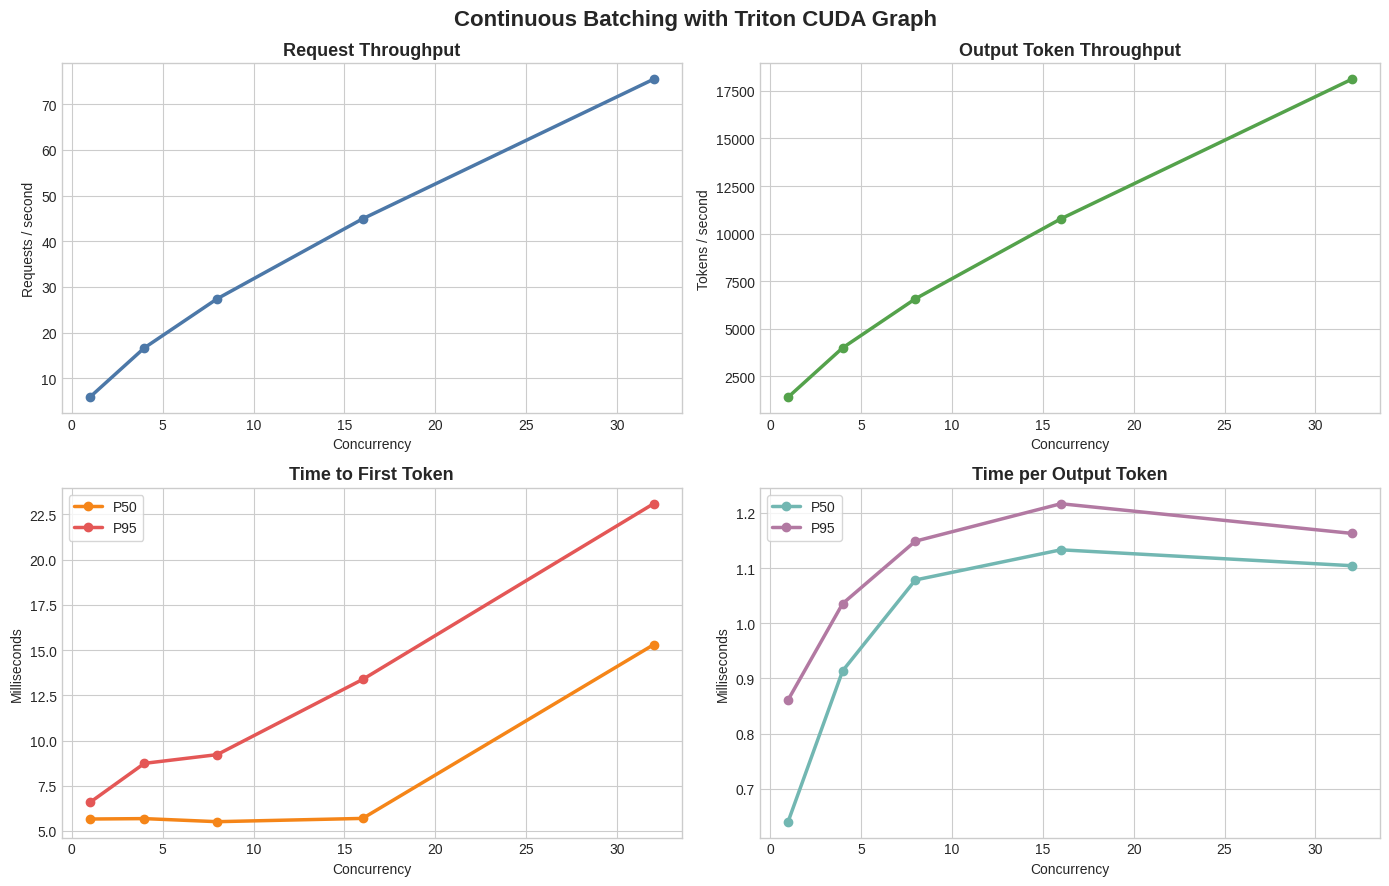

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
concurrency = continuous_results["concurrency"]

axes[0, 0].plot(concurrency, continuous_results["requests_s"], marker="o", linewidth=2.5, color="#4C78A8")
axes[0, 0].set_title("Request Throughput", fontsize=13, weight="bold")
axes[0, 0].set_xlabel("Concurrency")
axes[0, 0].set_ylabel("Requests / second")

axes[0, 1].plot(concurrency, continuous_results["output_tok_s"], marker="o", linewidth=2.5, color="#54A24B")
axes[0, 1].set_title("Output Token Throughput", fontsize=13, weight="bold")
axes[0, 1].set_xlabel("Concurrency")
axes[0, 1].set_ylabel("Tokens / second")

axes[1, 0].plot(concurrency, continuous_results["ttft_p50_ms"], marker="o", linewidth=2.5, color="#F58518", label="P50")
axes[1, 0].plot(concurrency, continuous_results["ttft_p95_ms"], marker="o", linewidth=2.5, color="#E45756", label="P95")
axes[1, 0].set_title("Time to First Token", fontsize=13, weight="bold")
axes[1, 0].set_xlabel("Concurrency")
axes[1, 0].set_ylabel("Milliseconds")
axes[1, 0].legend(frameon=True)

axes[1, 1].plot(concurrency, continuous_results["tpot_p50_ms"], marker="o", linewidth=2.5, color="#72B7B2", label="P50")
axes[1, 1].plot(concurrency, continuous_results["tpot_p95_ms"], marker="o", linewidth=2.5, color="#B279A2", label="P95")
axes[1, 1].set_title("Time per Output Token", fontsize=13, weight="bold")
axes[1, 1].set_xlabel("Concurrency")
axes[1, 1].set_ylabel("Milliseconds")
axes[1, 1].legend(frameon=True)

fig.suptitle("Continuous Batching with Triton CUDA Graph", fontsize=16, weight="bold")
fig.tight_layout()
plt.show()

测试 2 结果分析

- 当前 Mini-Inference 调度器采用 prefill 优先策略，prefill 与 decode 不会在同一调度轮中混合执行。测评开始时先加入达到 concurrency 上限的请求，请求完成后立即补入新请求，并优先完成新请求的 prefill；所有请求均已加入后，系统进入最终排空阶段，decode batch 随请求完成逐步减小。因此，实际平均 decode batch 通常低于设定的最大并发数。
- 随着 concurrency 增长，一轮 decode 可以同时为更多请求生成 token，模型权重读取、CPU 调度和 kernel 启动等固定开销得以在更多请求之间摊薄，因此请求吞吐和 output token 吞吐持续提高。但吞吐不会随并发线性增长，实际 decode batch 无法始终保持在并发上限，同时更大的 batch 会增加模型计算、kv cache 读取、输入准备和元数据传输，并逐渐受到显存带宽与 GPU 计算资源限制。CUDA Graph 只能降低固定的提交开销，不能消除这些随 batch 增长的工作量，所以并发越高，新增并发带来的边际吞吐收益越小。
- prefill 优先使新请求通常能在下一调度轮获得首 token，因此中低并发下 TTFT 相对稳定；当并发继续提高，单轮累计的 prompt 工作量跨过 GPU 的高效处理区间并接近调度器的 token 预算时，prefill 耗时会明显增加，所有请求的首 token 都需要等待这一轮完成，因而 TTFT 会出现较明显的跃升。TPOT 在并发增加初期会因 decode batch 变大、单轮 decode 变慢以及补入请求触发 prefill 中断而上升；并发进一步提高后，GPU 并行度和固定开销摊薄效果增强，在固定请求总量下，系统需要补入新请求的轮次减少并更早进入无 prefill 中断的排空阶段，这些因素可能使 TPOT 在达到峰值后有所回落。